Setup

In [6]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data") if Path("data").exists() else Path("../data")   # train.csv / validation.csv live here (git-ignored)
OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200, "display.max_columns", 50, "display.max_colwidth", 120)

train = pd.read_csv(DATA_DIR / "train.csv", keep_default_na=False)       # keep "" as "" (not NaN)
val = pd.read_csv(DATA_DIR / "validation.csv", keep_default_na=False)
train["split"], val["split"] = "train", "validation"
both = pd.concat([train, val], ignore_index=True)

def save(name):
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{name}.png", dpi=150)
    plt.show()

1. Overview 

In [7]:
for name, df in [("TRAIN", train), ("VALIDATION", val)]:
    print(f"===== {name}: {df.shape[0]} rows x {df.shape[1]} cols =====")
    print(df.dtypes, "\n")
print(train.head(3).T)

===== TRAIN: 4000 rows x 9 cols =====
ticket_id              str
channel                str
subject                str
text                   str
language               str
category               str
secondary_category     str
is_urgent             bool
split                  str
dtype: object 

===== VALIDATION: 800 rows x 9 cols =====
ticket_id              str
channel                str
subject                str
text                   str
language               str
category               str
secondary_category     str
is_urgent             bool
split                  str
dtype: object 

                                                                                                                                          0  \
ticket_id                                                                                                                      TF-TR-000554   
channel                                                                                                             

2. Missing Values 

In [8]:
def empty_report(df):
    return pd.DataFrame({
        "empty_count": (df.astype(str).apply(lambda s: s.str.strip()) == "").sum(),
        "empty_pct": ((df.astype(str).apply(lambda s: s.str.strip()) == "").mean() * 100).round(1),
    })
print("TRAIN\n", empty_report(train.drop(columns="split")), "\n")
print("VALIDATION\n", empty_report(val.drop(columns="split")))

TRAIN
                     empty_count  empty_pct
ticket_id                     0        0.0
channel                       0        0.0
subject                    2800       70.0
text                          0        0.0
language                      0        0.0
category                      0        0.0
secondary_category         3600       90.0
is_urgent                     0        0.0 

VALIDATION
                     empty_count  empty_pct
ticket_id                     0        0.0
channel                       0        0.0
subject                     560       70.0
text                          0        0.0
language                      0        0.0
category                      0        0.0
secondary_category          720       90.0
is_urgent                     0        0.0


3. Target: Category Balance 

                     train  train_%  val  val_%
category                                       
payment_refund         720     18.0  144   18.0
delivery_delay         600     15.0  120   15.0
ride_trip_issue        560     14.0  112   14.0
order_missing_wrong    480     12.0   96   12.0
account_promo          360      9.0   72    9.0
app_technical          320      8.0   64    8.0
food_quality           280      7.0   56    7.0
lost_item              200      5.0   40    5.0
general_inquiry        200      5.0   40    5.0
safety_conduct         160      4.0   32    4.0
spam_irrelevant        120      3.0   24    3.0

Imbalance ratio (largest/smallest, train): 6.0


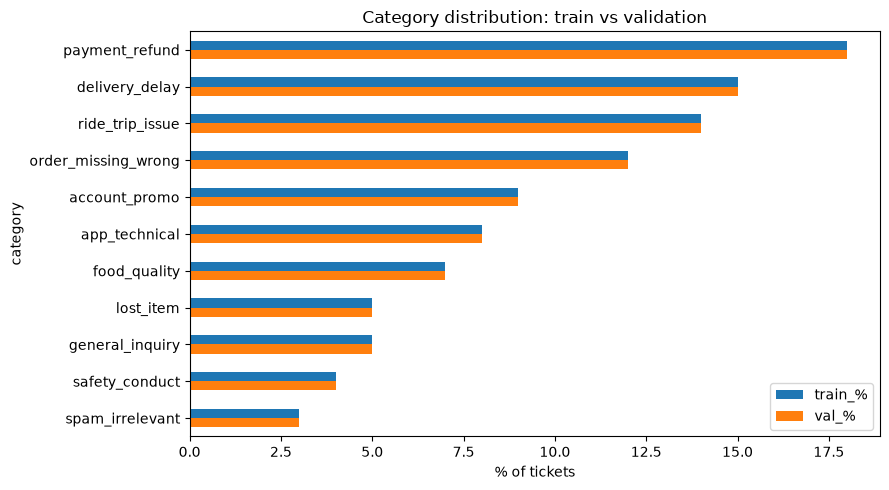

In [9]:
cat = pd.DataFrame({
    "train": train.category.value_counts(),
    "train_%": (train.category.value_counts(normalize=True) * 100).round(1),
    "val": val.category.value_counts(),
    "val_%": (val.category.value_counts(normalize=True) * 100).round(1),
}).sort_values("train", ascending=False)
print(cat)
print("\nImbalance ratio (largest/smallest, train):", round(cat.train.max() / cat.train.min(), 1))

fig, ax = plt.subplots(figsize=(9, 5))
cat[["train_%", "val_%"]].plot.barh(ax=ax)
ax.invert_yaxis(); ax.set_xlabel("% of tickets"); ax.set_title("Category distribution: train vs validation")
save("01_category_distribution")

4. Other columns: channel, language, is_urgent, secondary_category

--- channel ---
                 train  val  train_%  val_%
channel                                    
chat              1800  360     45.0   45.0
email             1200  240     30.0   30.0
call_transcript   1000  200     25.0   25.0

--- language ---
          train  val  train_%  val_%
language                            
en         1400  280     35.0   35.0
mixed       100   20      2.5    2.5
si          800  160     20.0   20.0
singlish   1000  200     25.0   25.0
ta          600  120     15.0   15.0
tanglish    100   20      2.5    2.5

--- is_urgent ---
           train  val  train_%  val_%
is_urgent                            
False       3600  720     90.0   90.0
True         400   80     10.0   10.0

--- secondary_category ---
                     train  val  train_%  val_%
secondary_category                             
(none)                3600  720     90.0   90.0
app_technical           45    9      1.1    1.1
delivery_delay          45    9      1.1    1.1
order_missi

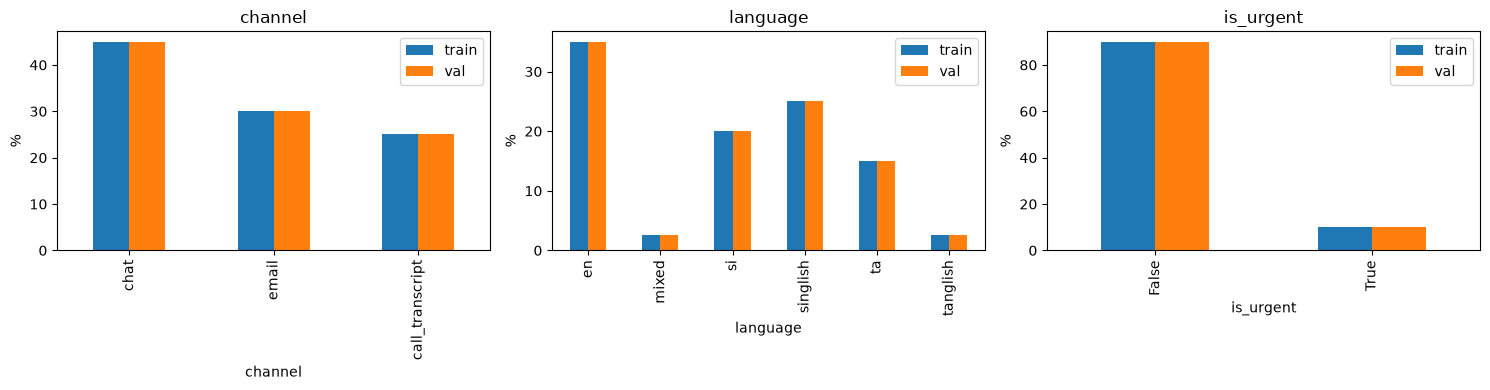

In [10]:
for col in ["channel", "language", "is_urgent", "secondary_category"]:
    t = pd.DataFrame({"train": train[col].replace("", "(none)").value_counts(),
                      "val": val[col].replace("", "(none)").value_counts()})
    t["train_%"] = (t.train / t.train.sum() * 100).round(1)
    t["val_%"] = (t.val / t.val.sum() * 100).round(1)
    print(f"--- {col} ---\n{t}\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["channel", "language", "is_urgent"]):
    pd.DataFrame({"train": train[col].value_counts(normalize=True),
                  "val": val[col].value_counts(normalize=True)}).mul(100).plot.bar(ax=ax)
    ax.set_title(col); ax.set_ylabel("%")
save("02_channel_language_urgent")

5. Category x language / channel / urgency (does the label depend on these?)

In [11]:
print("Category x language (row %):")
print((pd.crosstab(train.category, train.language, normalize="index") * 100).round(1), "\n")
print("Category x channel (row %):")
print((pd.crosstab(train.category, train.channel, normalize="index") * 100).round(1), "\n")
print("Urgent rate per category (%):")
print((train.groupby("category").is_urgent.mean() * 100).round(1).sort_values(ascending=False))

Category x language (row %):
language               en  mixed    si  singlish    ta  tanglish
category                                                        
account_promo        35.0    2.5  20.0      25.0  15.0       2.5
app_technical        35.0    2.5  20.0      25.0  15.0       2.5
delivery_delay       35.0    2.5  20.0      25.0  15.0       2.5
food_quality         35.0    2.5  20.0      25.0  15.0       2.5
general_inquiry      35.0    2.5  20.0      25.0  15.0       2.5
lost_item            35.0    2.5  20.0      25.0  15.0       2.5
order_missing_wrong  35.0    2.5  20.0      25.0  15.0       2.5
payment_refund       35.0    2.5  20.0      25.0  15.0       2.5
ride_trip_issue      35.0    2.5  20.0      25.0  15.0       2.5
safety_conduct       35.0    2.5  20.0      25.0  15.0       2.5
spam_irrelevant      35.0    2.5  20.0      25.0  15.0       2.5 

Category x channel (row %):
channel              call_transcript  chat  email
category                                      

6. Secondary category (only some tickets have one)

In [12]:
sec = train[train.secondary_category != ""]
print(f"Tickets with a secondary category: {len(sec)} ({len(sec)/len(train):.1%})")
print(pd.crosstab(sec.category, sec.secondary_category))
print("Primary == secondary anywhere?", (sec.category == sec.secondary_category).any())

Tickets with a secondary category: 400 (10.0%)
secondary_category   app_technical  delivery_delay  order_missing_wrong  payment_refund  ride_trip_issue
category                                                                                                
account_promo                   45               0                    0               0                0
delivery_delay                   0               0                    0              45                0
food_quality                     0               0                    0              45                0
lost_item                        0               0                    0               0               45
order_missing_wrong              0               0                    0              40                0
payment_refund                   0              45                   45               0               45
safety_conduct                   0               0                    0               0               45
Primary 

7. Text length (chars / words / lines) overall and per language

       n_chars  n_words  n_lines
count   4000.0   4000.0   4000.0
mean     318.0     49.8      6.2
std      155.3     27.6      5.1
min       36.0      4.0      1.0
25%      197.0     30.0      2.0
50%      275.5     42.0      5.0
75%      406.0     58.0      9.0
max      985.0    178.0     38.0 

         n_chars                  n_words                
            mean median  min  max    mean median min  max
language                                                 
en         414.2  427.5   49  985    72.6   73.5   6  178
mixed      291.6  265.5  155  534    43.7   42.5  26   76
si         241.9  218.0   36  547    38.1   35.0   4   80
singlish   260.6  252.0   37  510    39.4   38.0   5   75
ta         303.4  279.0   47  633    32.9   31.0   5   72
tanglish   267.0  238.5   49  507    36.0   33.5   6   71 

                n_chars                  n_words                
                   mean median  min  max    mean median min  max
channel                                        

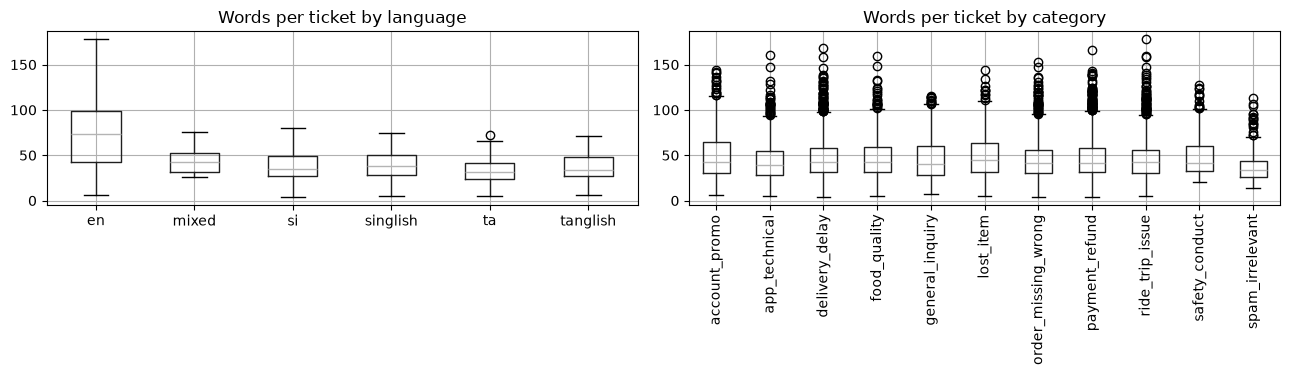

In [13]:
for df in (train, val, both):
    df["n_chars"] = df.text.str.len()
    df["n_words"] = df.text.str.split().str.len()
    df["n_lines"] = df.text.str.count("\n") + 1
print(train[["n_chars", "n_words", "n_lines"]].describe().round(1), "\n")
print(train.groupby("language")[["n_chars", "n_words"]].agg(["mean", "median", "min", "max"]).round(1), "\n")
print(train.groupby("channel")[["n_chars", "n_words"]].agg(["mean", "median", "min", "max"]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train.boxplot(column="n_words", by="language", ax=axes[0]); axes[0].set_title("Words per ticket by language"); axes[0].set_xlabel("")
train.boxplot(column="n_words", by="category", ax=axes[1], rot=90); axes[1].set_title("Words per ticket by category"); axes[1].set_xlabel("")
plt.suptitle("")
save("03_text_length")

8. Script detection (Sinhala / Tamil / Latin) vs the 'language' label

In [14]:
def script_mix(s):
    si = len(re.findall(r"[\u0D80-\u0DFF]", s))
    ta = len(re.findall(r"[\u0B80-\u0BFF]", s))
    la = len(re.findall(r"[A-Za-z]", s))
    tot = max(si + ta + la, 1)
    return pd.Series({"sinhala_%": si / tot, "tamil_%": ta / tot, "latin_%": la / tot})
sm = train.text.apply(script_mix)
print(sm.groupby(train.language).mean().mul(100).round(1))

          sinhala_%  tamil_%  latin_%
language                             
en              0.0      0.0    100.0
mixed          29.3     25.2     45.4
si             97.4      0.0      2.6
singlish        0.0      0.0    100.0
ta              0.0     98.0      2.0
tanglish        0.0      0.0    100.0


9. Duplicates & leakage (very important before training)

In [15]:
print("Duplicate ticket_id in train:", train.ticket_id.duplicated().sum())
print("Duplicate ticket_id in validation:", val.ticket_id.duplicated().sum())
print("ticket_id overlap train/val:", len(set(train.ticket_id) & set(val.ticket_id)))

norm = lambda s: re.sub(r"\s+", " ", s.strip().lower())
train["text_norm"], val["text_norm"] = train.text.map(norm), val.text.map(norm)
print("\nExact duplicate texts within train:", train.text_norm.duplicated().sum())
print("Exact duplicate texts within validation:", val.text_norm.duplicated().sum())
overlap = set(train.text_norm) & set(val.text_norm)
print("Texts appearing in BOTH train and validation:", len(overlap))

# Same text with different labels = label noise / ambiguity
conf = train.groupby("text_norm").category.nunique()
print("Texts with conflicting category labels in train:", (conf > 1).sum())
if len(overlap):
    leak = val[val.text_norm.isin(overlap)]
    print("\nLeaked validation rows (first 5):\n", leak[["ticket_id", "text", "category"]].head())

Duplicate ticket_id in train: 0
Duplicate ticket_id in validation: 0
ticket_id overlap train/val: 0

Exact duplicate texts within train: 0
Exact duplicate texts within validation: 0
Texts appearing in BOTH train and validation: 0
Texts with conflicting category labels in train: 0


10. Structured tokens in the text (reference codes, amounts, emoji, urls)

In [16]:
patterns = {
    "ref_code (e.g. SIMQ-V9LU2KD)": r"\b[A-Z]{2,6}-[A-Z0-9]{5,}\b",
    "amount (LKR / Rs / numbers)": r"(?:LKR|Rs\.?|රු\.?|ரூ)\s?\d[\d,]*",
    "any digit": r"\d",
    "emoji / symbols": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    "URL": r"https?://\S+|www\.\S+",
    "ALL CAPS word (4+)": r"\b[A-Z]{4,}\b",
    "exclamation !": r"!",
}
rows = {name: train.text.str.contains(p, regex=True).mean() * 100 for name, p in patterns.items()}
print(pd.Series(rows).round(1).rename("% of train tickets"))

ArrowInvalid: Invalid regular expression: invalid escape sequence: \U

11. Subject column: how useful is it?

In [ ]:
print("Subject empty (%):", round((train.subject == "").mean() * 100, 1))
print("Subject empty by channel (%):\n", (train.assign(e=train.subject == "").groupby("channel").e.mean() * 100).round(1))
print("\nUnique subjects:", train.subject.nunique())
print("\nTop 10 subjects per category (generic subjects carry little signal):")
for c, g in train[train.subject != ""].groupby("category"):
    print(f"  {c}: {g.subject.value_counts().head(3).to_dict()}")

12. Most distinctive words per category 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(lowercase=True, min_df=5, max_features=20000, token_pattern=r"(?u)\b\w\w+\b")
X = vec.fit_transform(train.text)
terms = np.array(vec.get_feature_names_out())
for c in sorted(train.category.unique()):
    mean_c = np.asarray(X[(train.category == c).values].mean(axis=0)).ravel()
    mean_rest = np.asarray(X[(train.category != c).values].mean(axis=0)).ravel()
    top = terms[np.argsort(mean_c - mean_rest)[::-1][:10]]
    print(f"{c:22s}: {', '.join(top)}")

13. Read some real examples 

In [ ]:
for c in sorted(train.category.unique()):
    print(f"\n######## {c}")
    for _, r in train[train.category == c].sample(2, random_state=42).iterrows():
        print(f"[{r.language}/{r.channel}] {r.text[:300]!r}")

14. Train vs validation drift check 

In [ ]:
print("Max abs difference in category % (train vs val):", (cat["train_%"] - cat["val_%"]).abs().max().round(2))
lang = pd.DataFrame({"train": train.language.value_counts(normalize=True), "val": val.language.value_counts(normalize=True)})
print("Max abs difference in language %:", ((lang.train - lang.val).abs().max() * 100).round(2))
print("Mean words  train vs val:", round(train.n_words.mean(), 1), round(val.n_words.mean(), 1))

15. Key findings to paste into report / experiments.md (fill in from the outputs above)

In [ ]:
print("""
Checklist:
- Rows: train=%d, validation=%d
- Target: 11 categories, imbalance ratio ~ see section 3  -> use stratified split, class_weight='balanced', macro-F1
- Languages: en, singlish, si, ta, tanglish, mixed -> use word + CHAR n-grams
- Leakage / duplicates: see section 9
- Text cleaning ideas: mask ref codes + amounts, normalise whitespace, keep emoji/!/CAPS (urgency/spam signal?)
- Team is NOT predicted: look up from the fixed category->team table in the schemas
""" % (len(train), len(val)))